<a href="https://colab.research.google.com/github/anuragpandey4/dl/blob/main/ann_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("./powerplant.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [ ]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [ ]:
X = df.drop(['PE'], axis=1)
y = df['PE']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [ ]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# creating and training the ann

In [ ]:
#define the model

class ANN(nn.Module):
  def __init__(self):
    super(ANN, self).__init__()

    self.model = nn.Sequential(
        #1 hidden layer
        nn.Linear(X.shape[1], 6),
        nn.ReLU(),

        #2 hidden layer
        nn.Linear(6, 6),
        nn.ReLU(),

        #output layer
        nn.Linear(6, 1),
    )

  def forward(self, x):
    return self.model(x)

In [ ]:
import torch.optim as optim

model = ANN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [ ]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch

    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()

        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update

        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 205978.16360677083 & val loss = 203466.953125
epoch 2/100 ==> train loss = 195816.9353515625 & val loss = 183854.9375
epoch 3/100 ==> train loss = 164170.86904296876 & val loss = 139780.046875
epoch 4/100 ==> train loss = 110107.10061848958 & val loss = 81576.421875
epoch 5/100 ==> train loss = 59915.52609049479 & val loss = 43111.25
epoch 6/100 ==> train loss = 32616.185432942708 & val loss = 24604.34765625
epoch 7/100 ==> train loss = 19524.880228678387 & val loss = 15641.0419921875
epoch 8/100 ==> train loss = 12933.111151123047 & val loss = 10688.69140625
epoch 9/100 ==> train loss = 9049.183474731446 & val loss = 7452.5849609375
epoch 10/100 ==> train loss = 6234.14689839681 & val loss = 5047.4453125
epoch 11/100 ==> train loss = 4212.424105326335 & val loss = 3419.6953125
epoch 12/100 ==> train loss = 2874.3360895792644 & val loss = 2369.242919921875
epoch 13/100 ==> train loss = 2002.2138366699219 & val loss = 1682.1737060546875
epoch 14/100 ==> trai

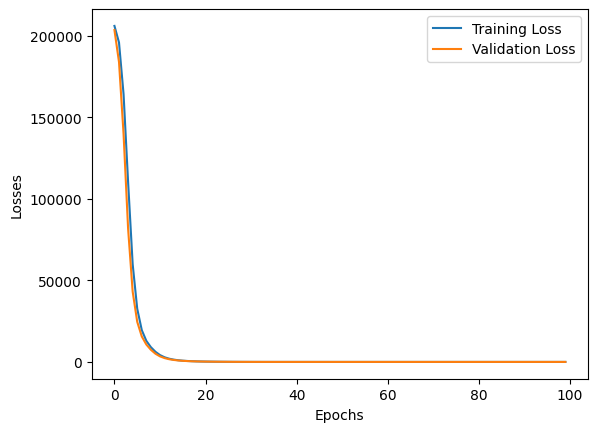

In [ ]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [ ]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [ ]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 21.366384506225586
Testing MSE: 19.595623016357422


In [ ]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.931518346470053


In [ ]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.082245,433.27
1,436.776154,438.16
2,461.486511,458.42
3,476.331451,480.82
4,435.755951,441.41
...,...,...
1909,450.890472,456.70
1910,431.467194,438.04
1911,467.406403,467.80
1912,430.994202,437.14
